### Task 5 - Model Iteration - BERT model 2


Importing all libraries that we will need to exxecute the code and run the model properly: 

In [20]:
import pandas as pd
import re
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
from collections import Counter
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    AdamW,
    get_scheduler,
)
from torch.utils.data import Dataset, DataLoader
import torch
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
# Load and clean dataset
df = pd.read_csv("processed_group 9_url1.csv", encoding="utf-8")
df = df.dropna(subset=["Corrected Sentence", "Emotion"])
df = df.drop_duplicates(subset=["Corrected Sentence", "Emotion"])

# Encode emotion labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["Emotion"])

# Split into train/test BEFORE resampling (avoids leakage)
df_train, df_test = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)

# FULL balancing: upsample all training classes to match the max class size
train_counts = df_train["Emotion"].value_counts()
max_count = train_counts.max()

train_balanced = (
    pd.concat(
        [
            resample(
                df_train[df_train["Emotion"] == label],
                replace=True,
                n_samples=max_count,
                random_state=42,
            )
            for label in train_counts.index
        ]
    )
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# Tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenization and encoding
train_encodings = tokenizer(
    list(train_balanced["Corrected Sentence"]),
    truncation=True,
    padding=True,
    return_tensors="pt",
)
test_encodings = tokenizer(
    list(df_test["Corrected Sentence"]),
    truncation=True,
    padding=True,
    return_tensors="pt",
)

train_labels = torch.tensor(train_balanced["label"].values, dtype=torch.long)
test_labels = torch.tensor(df_test["label"].values, dtype=torch.long)


# Custom dataset class
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


train_dataset = EmotionDataset(train_encodings, train_labels)
test_dataset = EmotionDataset(test_encodings, test_labels)

# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=len(label_encoder.classes_)
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=5e-5)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
num_training_steps = len(train_loader) * 10
lr_scheduler = get_scheduler(
    "linear", optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

# Training loop (no validation split)
best_model_path = "best_model.pt"
model.train()

for epoch in range(10):
    print(f"\nEpoch {epoch+1}/10")
    loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
    epoch_loss = 0
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        epoch_loss += loss.item()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")
    torch.save(model.state_dict(), best_model_path)
    print("✅ Model checkpoint saved!")

# Load the final model
model.load_state_dict(torch.load(best_model_path))
model.to(device)
print("\n✅ Final model loaded for testing!")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
d:\anaconda\envs\block_c_y2\lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(



Epoch 1/10


Training Epoch 1: 100%|██████████| 133/133 [02:28<00:00,  1.12s/it, loss=0.726]


Epoch 1 Loss: 1.1083
✅ Model checkpoint saved!

Epoch 2/10


Training Epoch 2: 100%|██████████| 133/133 [02:29<00:00,  1.12s/it, loss=0.0299]


...

Epoch 8 Loss: 0.0051
✅ Model checkpoint saved!

Epoch 9/10


Training Epoch 9: 100%|██████████| 133/133 [02:34<00:00,  1.16s/it, loss=0.003]  


Epoch 9 Loss: 0.0050
✅ Model checkpoint saved!

Epoch 10/10


Training Epoch 10: 100%|██████████| 133/133 [02:37<00:00,  1.19s/it, loss=0.0027] 


Epoch 10 Loss: 0.0047
✅ Model checkpoint saved!

✅ Final model loaded for testing!


##### Evaluation of the model

In [22]:
from sklearn.metrics import accuracy_score

model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=16):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        predictions.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(batch["labels"].cpu().numpy())

acc = accuracy_score(true_labels, predictions)
print(f"\n🧪 Test Accuracy: {acc:.4f}")


🧪 Test Accuracy: 0.5907


Further evaluation of the model: 


📊 Model Evaluation Metrics:
Accuracy  : 0.5907
Precision : 0.6067
Recall    : 0.5907
F1-score  : 0.5964

🔍 Classification Report:
              precision    recall  f1-score   support

       anger       0.38      0.38      0.38        13
     disgust       1.00      0.50      0.67         2
        fear       0.27      0.36      0.31        11
   happiness       0.65      0.65      0.65        57
     neutral       0.62      0.64      0.63        75
     sadness       0.27      0.31      0.29        13
    surprise       0.76      0.64      0.69        44

    accuracy                           0.59       215
   macro avg       0.56      0.50      0.52       215
weighted avg       0.61      0.59      0.60       215

🧩 Confusion Matrix:
[[ 5  0  3  3  1  1  0]
 [ 0  1  0  0  1  0  0]
 [ 0  0  4  2  3  2  0]
 [ 1  0  2 37 13  3  1]
 [ 1  0  3 14 48  3  6]
 [ 4  0  1  0  2  4  2]
 [ 2  0  2  1  9  2 28]]


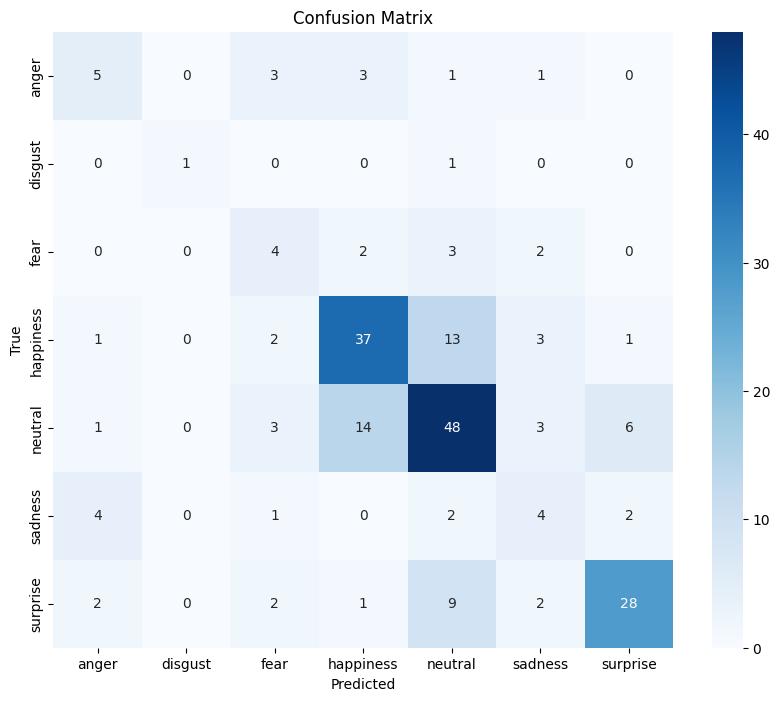

In [23]:
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=16):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()
        predictions.extend(preds)
        true_labels.extend(labels)

#convering to numpy arrays
y_pred = np.array(predictions)
y_true = np.array(true_labels)

#listing all he metrics
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

#printing overall metrics
print("\n📊 Model Evaluation Metrics:")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

#printing full classification report
class_names = label_encoder.classes_
print("\n🔍 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

#display of the confusion matrix
print("🧩 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


# Plotting the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Saving the model: 

In [24]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

#model.save_pretrained("emotion_model_BERT")
#tokenizer.save_pretrained("emotion_model_BERT5_tokenizer")